## Ejercicio 3 — Clasificación de fases en Modelo Ising 2D

En este ejercicio se trabajará con un conjunto de datos generado a partir de simulaciones del **modelo de Ising bidimensional (2D)** utilizando métodos de Monte Carlo (algoritmo de Metropolis).

El modelo de Ising describe un sistema de espines en una red cuadrada, donde cada sitio puede tomar valores:

* (+1) (espín “arriba”)
* (-1) (espín “abajo”)

Los espines vecinos tienden a alinearse, pero la temperatura introduce fluctuaciones térmicas que pueden desordenar el sistema.

El comportamiento del sistema depende de la temperatura:

* **Temperatura baja $(T < T_c)$**:
  el sistema tiende a ordenarse, formando dominios grandes de espines alineados.

* **Temperatura alta $(T > T_c)$**:
  el sistema permanece desordenado debido a las fluctuaciones térmicas.

Existe una **temperatura crítica** conocida:

$$
T_c \approx 2.269
$$

en la cual ocurre una transición de fase entre el estado ordenado y desordenado.

Se provee un dataset compuesto por configuraciones del modelo de Ising. Los datos se encuentran en `.data/ising_dataset.pt`. Cada muestra corresponde a un vector de 625 elementos, que corresponden al aplanamiento de **imagen (grilla 2D)** $25\times 25$ de espines. Cada imagen fue generada a una cierta temperatura y tiene una etiqueta asociada a si se encuentra por encima o por debajo de $T_C$:

  * $y = 0$: temperatura **por debajo** de $T_c$
  * $y = 1$: temperatura **por encima** de $T_c$


Entrenar un modelo de clasificación supervisada que, dada una configuración del sistema, sea capaz de predecir si corresponde a:

* fase ordenada ((T < T_c))
* fase desordenada ((T > T_c))

utilizando un perceptrón multicapa (MLP) utilizando el vector de datos provisto y una red neuronal convolucional (CNN) transformando el vector en un arreglo de 2 dimensiones (imagen). Para esto, utilizar una función de pérdida adecuada para clasificación binaria. Comparar los resultados entre ambas arquitecturas comparando la **accuracy** en cada caso.


In [2]:
import torch
from torch import nn
from torch.utils.data import DataLoader

# cargar datos de ising_dataset.pt
data = torch.load("data/ising_dataset.pt")

In [3]:
# Creamos Batchs
dataloader = DataLoader(list(zip(data["X_train"], data["y_train"])), batch_size=32, shuffle=True)

In [26]:
# Definición del perceptrón multicapa para clasificación binaria
class MLP(nn.Module):
    def __init__(self, input_dim=625, hidden_N=32, hidden_L=3, dropout_p=0.3):
        super().__init__()

        # Construimos dinámicamente las capas en una lista
        layers = []

        # Primera capa: de la entrada (625 features) a la capa oculta
        layers.append(nn.Linear(input_dim, hidden_N))
        layers.append(nn.ReLU())
        layers.append(nn.Dropout(dropout_p))

        # Capas ocultas adicionales (hidden_L - 1)
        for _ in range(hidden_L - 1):
            layers.append(nn.Linear(hidden_N, hidden_N))
            layers.append(nn.ReLU())
            layers.append(nn.Dropout(dropout_p))

        # Capa final: un único logit para BCEWithLogitsLoss
        layers.append(nn.Linear(hidden_N, 1))

        # Empaquetamos todo como una red secuencial
        self.net = nn.Sequential(*layers)

    # Forward: define cómo fluye x por la red
    def forward(self, x):
        return self.net(x)
    
# Defino una red convolucional simple para clasificación binaria en el dataset de Ising.
class CNN(nn.Module):
    def __init__(self, input_channels=1, hidden_channels=16, num_classes=1, dropout_p=0.25):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(input_channels, hidden_channels, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),  # 25x25 -> 12x12
            nn.Dropout2d(dropout_p),
            nn.Conv2d(hidden_channels, hidden_channels * 2, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),  # 12x12 -> 6x6
            nn.Dropout2d(dropout_p),
            nn.Flatten(),
            nn.Linear((hidden_channels * 2) * 6 * 6, num_classes),
        )

    def forward(self, x):
        return self.net(x)

In [27]:
# -------------------- Entrenamiento --------------------
def train(model, dataloader, X_test, y_test, criterion, optimizer, num_epochs=50, is_cnn=False):
    train_losses = []
    test_losses = []
    best_test_loss = float("inf")
    best_state_dict = None

    for epoch in range(num_epochs):
        model.train()  # modo entrenamiento
        epoch_train_loss = 0.0

        # Entrenamiento por mini-batches
        for X_batch, y_batch in dataloader:
            if is_cnn:
                X_batch = X_batch.view(-1, 1, 25, 25)

            y_batch = y_batch.view(-1).float()

            optimizer.zero_grad()  # limpiar gradientes
            logits = model(X_batch).view(-1)  # logits binarios
            loss = criterion(logits, y_batch)
            loss.backward()  # backward pass por batch
            optimizer.step()  # actualización de parámetros

            epoch_train_loss += loss.item()

        train_loss = epoch_train_loss / len(dataloader)
        train_losses.append(train_loss)

        # Evaluar en el conjunto de prueba
        model.eval()  # modo evaluación
        with torch.no_grad():
            X_test_eval = X_test.view(-1, 1, 25, 25) if is_cnn else X_test
            y_test_idx = y_test.view(-1).float()
            test_logits = model(X_test_eval).view(-1)
            test_loss = criterion(test_logits, y_test_idx)
            current_test_loss = test_loss.item()
            test_losses.append(current_test_loss)

            # Guardar los mejores parámetros según test_loss
            if current_test_loss < best_test_loss:
                best_test_loss = current_test_loss
                best_state_dict = {k: v.detach().clone() for k, v in model.state_dict().items()}

        if (epoch + 1) % 10 == 0:
            print(
                f"Epoch [{epoch+1}/{num_epochs}], "
                f"Train Loss: {train_loss:.4f}, Test Loss: {current_test_loss:.4f}"
            )

    # Restaurar el mejor modelo antes de devolver resultados
    if best_state_dict is not None:
        model.load_state_dict(best_state_dict)

    return train_losses, test_losses

In [28]:
criterion = nn.BCEWithLogitsLoss()  # Para clasificación binaria con salida sin softmax
MLP_model = MLP(input_dim=data["X_train"].shape[1], hidden_N=8, hidden_L=2, dropout_p=0.3)

In [35]:
optimizer_mlp = torch.optim.Adam(MLP_model.parameters(), lr=0.001, weight_decay= 1e-1)

# Calculamos la cantidad de parámetros entrenables en la MLP
mlp_params = sum(p.numel() for p in MLP_model.parameters() if p.requires_grad)
print(f"MLP parámetros entrenables (exactos): {mlp_params:,}")

MLP_train_losses, MLP_test_losses = train(
    MLP_model,
    dataloader,
    data["X_test"],
    data["y_test"],
    criterion,
    optimizer_mlp,
    num_epochs=100,
    is_cnn=False,
)

MLP parámetros entrenables (exactos): 5,089
Epoch [10/100], Train Loss: 0.3457, Test Loss: 0.4852
Epoch [20/100], Train Loss: 0.3439, Test Loss: 0.4744
Epoch [30/100], Train Loss: 0.3441, Test Loss: 0.4767
Epoch [40/100], Train Loss: 0.3405, Test Loss: 0.4795
Epoch [50/100], Train Loss: 0.3432, Test Loss: 0.4758
Epoch [60/100], Train Loss: 0.3314, Test Loss: 0.4792
Epoch [70/100], Train Loss: 0.3346, Test Loss: 0.4779
Epoch [80/100], Train Loss: 0.3304, Test Loss: 0.4763
Epoch [90/100], Train Loss: 0.3445, Test Loss: 0.4785
Epoch [100/100], Train Loss: 0.3461, Test Loss: 0.4766


In [36]:
CNN_model = CNN(input_channels=1, hidden_channels=16, num_classes=1, dropout_p=0.25)
optimizer_cnn = torch.optim.Adam(CNN_model.parameters(), lr=0.001, weight_decay= 1e-5)

#Calculamos la cantidad de parámetros entrenables en la CNN
cnn_params = sum(p.numel() for p in CNN_model.parameters() if p.requires_grad)
print(f"CNN parámetros entrenables (exactos): {cnn_params:,}")

CNN_train_losses, CNN_test_losses = train(
    CNN_model,
    dataloader,
    data["X_test"],
    data["y_test"],
    criterion,
    optimizer_cnn,
    num_epochs=100,
    is_cnn=True,
)

CNN parámetros entrenables (exactos): 5,953
Epoch [10/100], Train Loss: 0.1275, Test Loss: 0.0549
Epoch [20/100], Train Loss: 0.0786, Test Loss: 0.0563
Epoch [30/100], Train Loss: 0.0830, Test Loss: 0.0613
Epoch [40/100], Train Loss: 0.0415, Test Loss: 0.0584
Epoch [50/100], Train Loss: 0.0379, Test Loss: 0.0961
Epoch [60/100], Train Loss: 0.0170, Test Loss: 0.0648
Epoch [70/100], Train Loss: 0.0250, Test Loss: 0.0747
Epoch [80/100], Train Loss: 0.0134, Test Loss: 0.0863
Epoch [90/100], Train Loss: 0.0103, Test Loss: 0.0802
Epoch [100/100], Train Loss: 0.0115, Test Loss: 0.0953


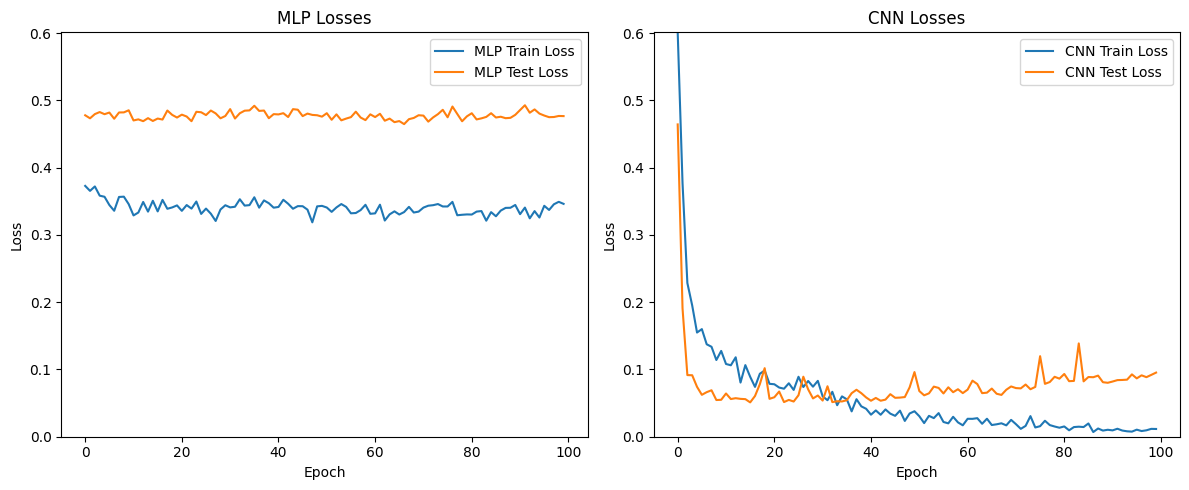

In [37]:
#Graficamos las pérdidas de entrenamiento y prueba para ambos modelos
import matplotlib.pyplot as plt
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(MLP_train_losses, label="MLP Train Loss")
plt.plot(MLP_test_losses, label="MLP Test Loss")
plt.title("MLP Losses")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.ylim(0, max(max(MLP_train_losses + MLP_test_losses), max(CNN_train_losses + CNN_test_losses)))

plt.legend()    
plt.subplot(1, 2, 2)
plt.plot(CNN_train_losses, label="CNN Train Loss")
plt.plot(CNN_test_losses, label="CNN Test Loss")
plt.title("CNN Losses")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.ylim(0, max(max(MLP_train_losses + MLP_test_losses), max(CNN_train_losses + CNN_test_losses)))
plt.tight_layout()
plt.show()

In [41]:
import pandas as pd


def calculate_accuracy(model, X, y, is_cnn=False):
    model.eval()
    with torch.no_grad():
        X_eval = X.view(-1, 1, 25, 25) if is_cnn else X
        logits = model(X_eval).view(-1)
        predicted = (torch.sigmoid(logits) >= 0.5).long()
        correct = (predicted == y.view(-1).long()).sum().item()
        total = y.size(0)
    return correct / total

mlp_train_acc = calculate_accuracy(MLP_model, data["X_train"], data["y_train"])
mlp_test_acc = calculate_accuracy(MLP_model, data["X_test"], data["y_test"])
cnn_train_acc = calculate_accuracy(CNN_model, data["X_train"], data["y_train"], is_cnn=True)
cnn_test_acc = calculate_accuracy(CNN_model, data["X_test"], data["y_test"], is_cnn=True)

accuracy_table = pd.DataFrame({
    "Train Accuracy": [mlp_train_acc, cnn_train_acc],
    "Test Accuracy": [mlp_test_acc, cnn_test_acc],
}, index=["MLP", "CNN"])

accuracy_table

,Train Accuracy,Test Accuracy
MLP,0.99500,0.80
CNN,0.98375,0.98


Podemos ver que para $\approx 5000$ parámetros y 50 épocas, la loss del training tiende a cero en ambos modelos. Sin embargo, en la MLP la loss del test diverge rápidamente, indicando un posible overfitting. Se introdujo dropout para reducir este efecto y reforzar la regularización, aunque no elimina por completo la sensibilidad al ajuste de hiperparámetros.

Por otro lado, la CNN en pocas épocas consiguió disminuir ambas losses a valores bajos, donde la test loss alcanzó un nivel estacionario mientras que la train loss siguió bajando. El dropout ayuda a estabilizar ese comportamiento y a limitar la sobreconfianza del modelo.

Finalmente, la CNN superó a la MLP tanto en la Train Accuracy como en la Test Accuracy, alcanzando fácilmente y en pocas épocas una Test Accuracy = 0.99.


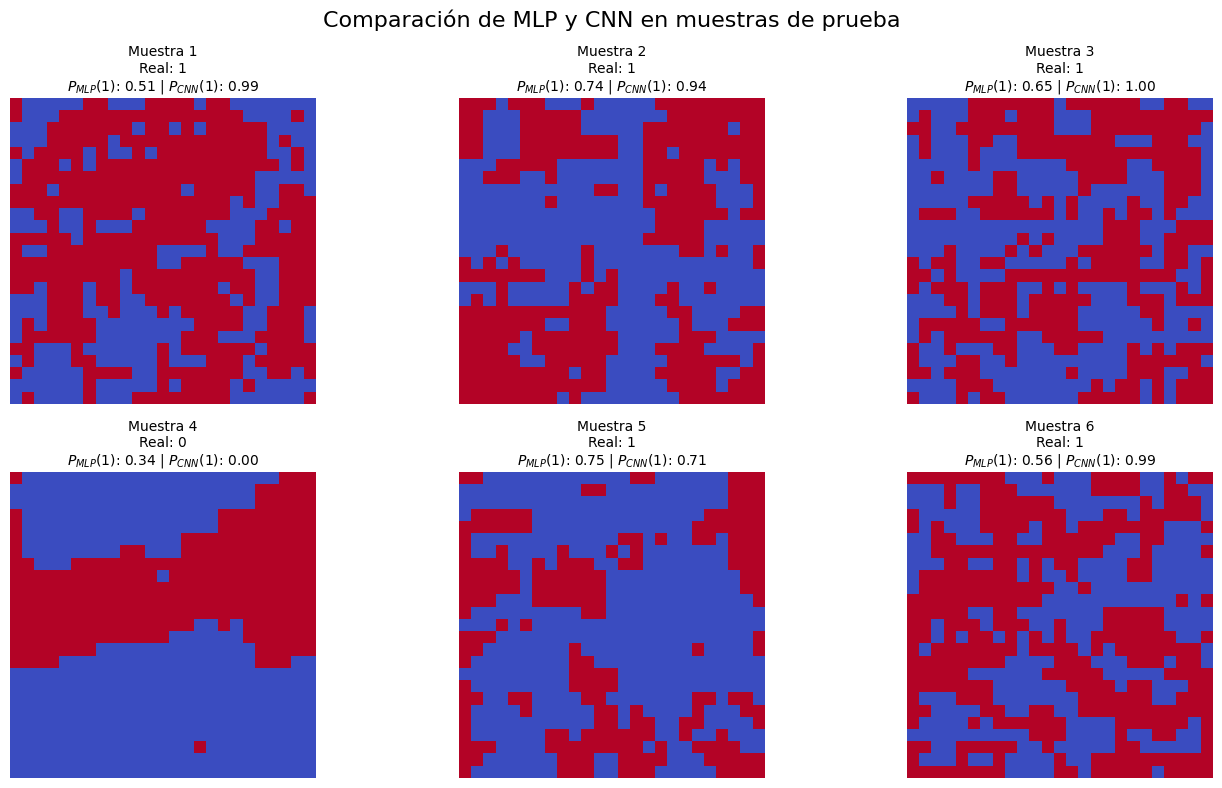

,Fase real,P(1) MLP,P(1) CNN
Muestra 1,1,0.507537,0.991084
Muestra 2,1,0.742955,0.943043
Muestra 3,1,0.651272,0.997353
Muestra 4,0,0.336498,0.001054
Muestra 5,1,0.754100,0.706762
Muestra 6,1,0.561978,0.994400


In [39]:
import matplotlib.pyplot as plt
import pandas as pd

# Obtiene probabilidades y clases predichas para un lote de muestras.
def predict_batch(model, X, is_cnn=False):
    model.eval()
    with torch.no_grad():
        # La CNN necesita el vector aplanado con forma de imagen 25x25.
        X_eval = X.view(-1, 1, 25, 25) if is_cnn else X
        logits = model(X_eval).view(-1)
        probs = torch.sigmoid(logits)
        preds = (probs >= 0.5).long()
    return probs, preds

# Tomamos muestras al azar del conjunto de prueba para compararlas visualmente.
num_samples = 6
sample_indices = torch.randperm(len(data["X_test"]))[:num_samples]
X_samples = data["X_test"][sample_indices]
y_samples = data["y_test"][sample_indices].view(-1).long()

# Predicciones de ambos modelos sobre las mismas muestras.
mlp_probs, mlp_preds = predict_batch(MLP_model, X_samples, is_cnn=False)
cnn_probs, cnn_preds = predict_batch(CNN_model, X_samples, is_cnn=True)

# Graficamos cada configuración como una imagen 25x25.
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.ravel()
plt.suptitle("Comparación de MLP y CNN en muestras de prueba", fontsize=16)
for i, ax in enumerate(axes):
    image = X_samples[i].view(25, 25).cpu().numpy()
    # La etiqueta real se muestra como fase, mientras que las predicciones se muestran como probabilidad de clase 1.
    true_phase = 0 if y_samples[i].item() == 0 else 1
    mlp_prob = mlp_probs[i].item()
    cnn_prob = cnn_probs[i].item()

    ax.imshow(image, cmap="coolwarm", interpolation="nearest")
    ax.set_title(
        f"Muestra {i + 1}\n"
        f"Real: {true_phase}\n"
        fr"$P_{{MLP}}(1)$: {mlp_prob:.2f} | $P_{{CNN}}(1)$: {cnn_prob:.2f}"
        ,
        fontsize=10
    )
    ax.axis("off")

# Mostramos la figura y armamos una tabla resumen con las etiquetas y predicciones.
plt.tight_layout()
plt.show()

comparison_table = pd.DataFrame({
    "Fase real": [0 if y.item() == 0 else 1 for y in y_samples],
    "P(1) MLP": [p.item() for p in mlp_probs],
    "P(1) CNN": [p.item() for p in cnn_probs],
}, index=[f"Muestra {i + 1}" for i in range(num_samples)])

comparison_table

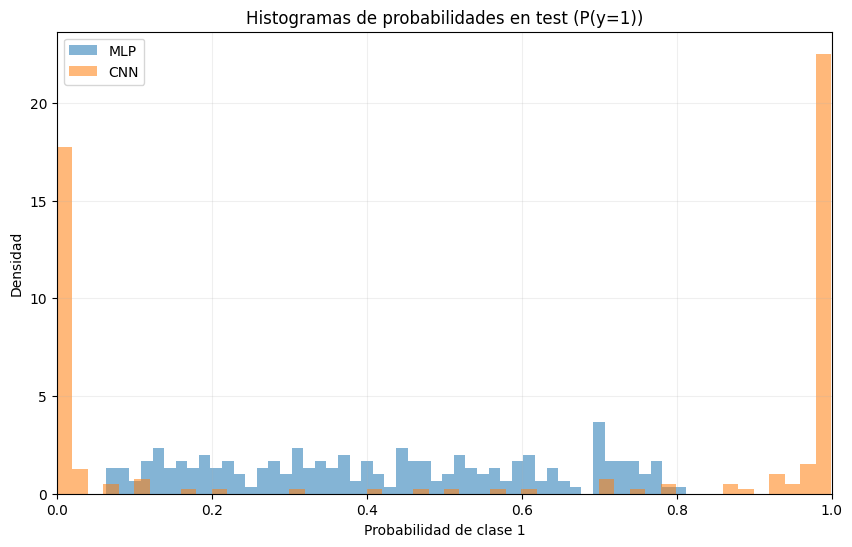

In [40]:
# Probabilidades P(y=1) de ambos modelos sobre TODO el conjunto de test
with torch.no_grad():
    mlp_test_probs = torch.sigmoid(MLP_model(data["X_test"]).view(-1)).cpu().numpy()
    cnn_test_input = data["X_test"].view(-1, 1, 25, 25)
    cnn_test_probs = torch.sigmoid(CNN_model(cnn_test_input).view(-1)).cpu().numpy()

plt.figure(figsize=(10, 6))
bins = 50

plt.hist(mlp_test_probs, bins=bins, alpha=0.55, label="MLP", density=True)
plt.hist(cnn_test_probs, bins=bins, alpha=0.55, label="CNN", density=True)

plt.title("Histogramas de probabilidades en test (P(y=1))")
plt.xlabel("Probabilidad de clase 1")
plt.ylabel("Densidad")
plt.xlim(0, 1)
plt.legend()
plt.grid(alpha=0.2)
plt.show()

Otra cosa interesante para notar es la diferencia en dispersión entre ambos modelos. Si interpretamos los logits como probabilidades, la CNN tiene mucha más seguridad sobre sus predicciones, es decir, arroja probabilidades muy cercanas a cero o uno. Mientras que la MLP tiene una distribución de probabilidad más uniforme.